<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/(ANN_Regression_%26_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Program- Student Marks Prediction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [2]:
X=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y=np.array([30,35,50,55,65,75,80,90])

In [3]:
#Model
model=Sequential()
model.add(Dense(10,activation='relu',input_shape=(1,)))
model.add(Dense(5,activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(optimizer='adam',loss='mse')

In [7]:
history = model.fit(X, y, epochs=100, verbose=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted Marks for 9 hours: [[0.09984057]]


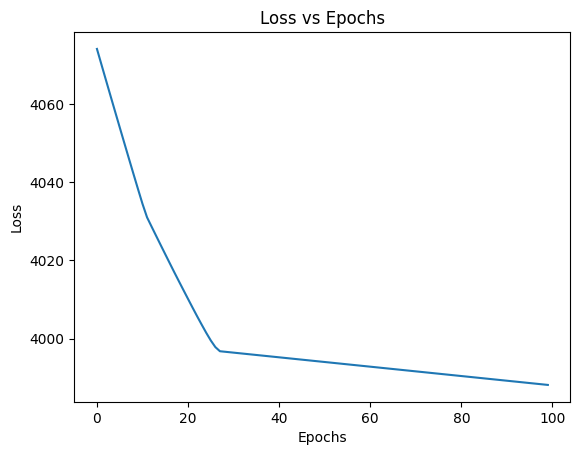

In [9]:
print("Predicted Marks for 9 hours:", model.predict(np.array([[9]]))) # Corrected input to np.array

# Plot Loss
plt.plot(history.history['loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Why No Activation in Output (Regression)

#### 🔹 Regression Output

We want values like:

`45, 72, 88.5` (any real number)

#### ❌ Problem with Activation

If you use:

*   **Sigmoid** → output between 0 and 1
*   **ReLU** → no negative values

👉 This restricts output

#### ✅ So we use:

`model.add(Dense(1))`  _# No activation_

#### 🧠 Logic

Let model output be:

`y = WX + b`

👉 This allows:

Any real value (−∞ to +∞)

#### 🔥 Exception

If marks are normalized (0–1), then sigmoid can be used.

### Why We Use MSE Loss

#### 🔹 MSE = Mean Squared Error

`MSE = (1/n) * Σ (y_i - ŷ_i)^2`

#### 🔹 Meaning
*   `y_i` → actual value
*   `ŷ_i` → predicted value

👉 Measures average squared error

#### 🔥 Why Squared?
*   Penalizes large errors more
*   Always positive
*   Smooth → easy for optimization

#### 🧠 Example

Actual = 80
Predicted = 70

Error:

`(80 - 70)^2 = 100`

#### 🔥 Why MSE in Regression?
*   Works with continuous values
*   Differentiable → helps gradient descent
*   Standard choice in ML

### How Model Learns Patterns

This is the most important concept.

#### 🔹 Step-by-Step Learning
1.  **Forward Pass**
    *   Input → goes through layers
    *   Output is predicted
2.  **Loss Calculation**
    *   Compare prediction vs actual
    *   Compute error (MSE)
3.  **Backpropagation**
    *   Calculate gradients (error contribution)
    *   Adjust weights
4.  **Weight Update**

    Using Gradient Descent:

    `W = W - η * (dL/dW)`

#2. Spam Detection

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
data = {
    "email": [
        "Win money now",
        "Hello friend",
        "Free offer just for you",
        "Meeting tomorrow",
        "Claim your prize now",
        "Let's study together"
    ],
    "label": [1,0,1,0,1,0]  # 1 = Spam, 0 = Not Spam
}

df = pd.DataFrame(data)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

In [22]:
X=vectorizer.fit_transform(df['email']).toarray()
y=df['label']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [24]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [26]:
model.fit(X_train,y_train,epochs=50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6944
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.6925
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6909
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6897
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6887
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7500 - loss: 0.6878
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7500 - loss: 0.6868
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7500 - loss: 0.6859
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7500 - loss: 0.6849
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6840
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7500 - loss: 0.6830
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6821
Epo

In [27]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

# Predict new email
sample = vectorizer.transform(["Free money offer"]).toarray()
prediction = model.predict(sample)

print("Spam" if prediction > 0.5 else "Not Spam")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 1.0000 - loss: 0.6583
Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Not Spam


In [28]:
print(prediction)

[[0.49922764]]


#House Price Prediction (Multiple Inputs)

In [30]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# area, bedrooms, age
X = np.array([
    [1000, 2, 5],
    [1500, 3, 10],
    [1800, 4, 2],
    [1200, 2, 8],
    [2000, 5, 1]
])

y = np.array([50, 70, 90, 60, 120])  # price

model = Sequential([
    Dense(10, activation='relu', input_shape=(3,)),
    Dense(5, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100)

print(model.predict(np.array([[1700, 3, 4]])))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step - loss: 332.1984
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 201.3947
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 113.1862
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 66.6636
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 56.5667
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 71.3796
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 94.8936
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 112.7489
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 118.1505
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 111.6289
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 97.5907
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 81.3418
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 67.3918
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 58.6259
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 55.9886

#Program . Iris Flower Classification (MULTI-CLASS)

In [31]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [32]:
data = load_iris()
X = data.data
y = data.target

In [33]:
y=to_categorical(y,3)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [35]:
model = Sequential()
model.add(Dense(10, activation='relu', input_shape=(4,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])


In [37]:
model.fit(X_train, y_train, epochs=100)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3905 - loss: 1.1911
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6381 - loss: 1.1330
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 1.0872
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6762 - loss: 1.0447
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6762 - loss: 1.0087
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6762 - loss: 0.9775
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6762 - loss: 0.9533
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6762 - loss: 0.9338
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6762 - loss: 0.9218
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6762 - loss: 0.9087
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6762 - loss: 0.8969
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6762 - lo

In [38]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

# Predict
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = model.predict(sample)

print("Prediction Probabilities:", prediction)
print("Predicted Class:", np.argmax(prediction))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9778 - loss: 0.2903 
Accuracy: 0.9777777791023254


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Prediction Probabilities: [[0.9229835  0.07594379 0.00107268]]
Predicted Class: 0


In [39]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9762 - loss: 0.2703 - val_accuracy: 1.0000 - val_loss: 0.2074
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9762 - loss: 0.2677 - val_accuracy: 1.0000 - val_loss: 0.2042
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9762 - loss: 0.2653 - val_accuracy: 1.0000 - val_loss: 0.2016
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9762 - loss: 0.2623 - val_accuracy: 1.0000 - val_loss: 0.1977
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9762 - loss: 0.2599 - val_accuracy: 1.0000 - val_loss: 0.1945
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9762 - loss: 0.2576 - val_accuracy: 1.0000 - val_loss: 0.1924
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9643 - loss: 0.2559 - val_accuracy: 1.0000 - val_loss: 0.1898
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9643 - loss: 0.2528 - val_accuracy: 1.0000 - val_loss

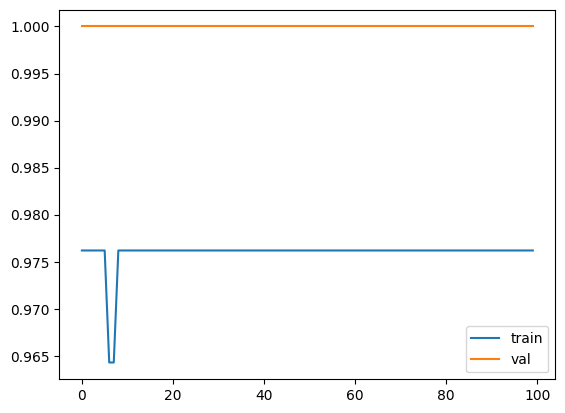

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()